# Public negative-N1 development model: a held-out participant

Apply a portable N1 annotation classifier to one actual ds004774 record, verify its saved held-out prediction, and inspect its feature contributions.

All features in this notebook derive from actual public OpenNeuro ds004774 recordings. The example model excluded its participant from fitting and threshold selection. Run cells from top to bottom; input and model checksums are verified before use.

In [1]:
from dataclasses import asdict
import hashlib
import json
from pathlib import Path
import platform
import sys
from tempfile import TemporaryDirectory

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display as show_output

HERE = Path.cwd()
REPOSITORY = HERE if (HERE / "ERPy").is_dir() else HERE.parents[1]
assert (REPOSITORY / "validation" / "frozen_results" / "n1").is_dir()
sys.path.insert(0, str(REPOSITORY.resolve()))
import ERPy as ep

get_ipython().run_line_magic("matplotlib", "inline")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11, "savefig.bbox": "tight"})

This optional classifier targets early **negative N1 annotations in cortical-surface
ECoG**. Default ERPy remains polarity-invariant; its p/q values and calls are
unchanged. A logistic N1 score is **not a p value, q value or established
out-of-population probability**, and this model is not validated for sEEG.

The source is CC0 [OpenNeuro ds004774 v1.0.0](https://doi.org/10.18112/openneuro.ds004774.v1.0.0).
We use frozen features and matching inference from recorded signals, with no
synthetic substitution or invented waveform. No raw download or scikit-learn
is required. Install ERPy plus Jupyter to run these cells.

The extension was developed after the original evaluation was examined.
Participant-held-out predictions are development cross-validation, not a new
untouched external validation. A deterministic identifier-join correction
required a full rerun after preliminary outcomes had been seen; the correction
receipt and both authentic protocol revisions accompany the final evidence.
See `docs/N1_DEVELOPMENT.md` for training and reproduction.

In [2]:
from ERPy.n1 import N1MorphologyModel, n1_feature_vector
from validation.verify_n1_artifacts import verify
from validation.verify_n1_input_contract import verify as verify_input_contract
from validation.n1_frozen_inputs import FrozenN1Inputs
from validation.score_erdetect_validation import canonicalize, require_unique

N1_ROOT = REPOSITORY / "validation" / "frozen_results" / "n1"
print(verify(N1_ROOT))  # Verifies every packaged artifact and the shared inference table.
manifest = json.loads((N1_ROOT / "artifact_manifest.json").read_text())
entries = {item["path"]: item for group in ("files", "external_inputs") for item in manifest[group]}

# Require the current checked-interface replay, bound to these exact source files.
contract_output = REPOSITORY / "validation/n1_input_contract"
print(verify_input_contract(contract_output))
contract_receipt = json.loads((contract_output / "verification.json").read_text())
assert contract_receipt["changed_calls"] == 0
assert contract_receipt["individual_prediction_checks"] == 128192
checked_inputs = FrozenN1Inputs(N1_ROOT)

features = canonicalize(pd.read_csv(N1_ROOT / "features/n1_features.csv.gz"))
KEY = ["subject", "stimpair", "channel"]
require_unique(features, KEY, "public N1 features")
record_columns = KEY + [
    "configuration", "scoring_eligible", "evaluable", "archived_record_present",
    "archived_pair_comparable", "reference_positive", "development_overlap",
    "epoch_sha256", "p_reproducibility", "p_energy", "p_joint", "q_joint",
    "rms_ratio_db", "detected", "n_trials_total", "n_trials_clean", "random_seed",
]
records = pd.read_csv(
    N1_ROOT / "../erdetect/record_predictions_and_labels.csv.gz",
    usecols=record_columns, low_memory=False, dtype={"random_seed": "string"},
)
print(f"ERPy {ep.__version__}; Python {platform.python_version()}")
print(f"{len(features):,} recorded contact/pair feature rows; all source identities verified")

{'status': 'verified', 'files': 91, 'external_inputs': 1}
{'status': 'verified', 'artifacts': 42, 'prediction_checks': 128192}


ERPy 1.1.0rc1; Python 3.12.5
36,016 recorded contact/pair feature rows; all source identities verified


Selection rule: use the **first lexicographic feature-available MAYO02 record**
in the frozen early-window paired evaluation frame. Eligibility includes a
reference being present; its value, model score and detector call do not select
the record. The join uses the scorer's exact undirected pair convention and
requires matching epoch hashes. Identifier columns locate the record and are
never model features.

In [3]:
eligible = (
    records.configuration.eq("early_10_90ms") & records.scoring_eligible
    & records.evaluable & records.archived_record_present
    & records.archived_pair_comparable & records.reference_positive.notna()
    & ~records.development_overlap
)
frame = canonicalize(records.loc[eligible]).merge(
    features, on=KEY, how="left", validate="one_to_one", suffixes=("", "_feature"),
)
assert len(frame) == 32048 and frame.subject.nunique() == 13
assert frame.feature_available.all()
assert frame.epoch_sha256.eq(frame.epoch_sha256_feature).all()
row = frame.loc[frame.subject.eq("MAYO02") & frame.feature_available].sort_values(KEY).iloc[0]
feature_record, inference = checked_inputs.prepare(
    checked_inputs.features.loc[tuple(row[key] for key in KEY)], row.to_dict(),
)
print("Trial provenance:", feature_record["_n1_input_provenance"]["trial_provenance_scope"])
print("Selected public record:", " / ".join(str(row[key]) for key in KEY))
print("Feature contract:", row.feature_version, row.voltage_unit, row.feature_config_sha256)
show_output(row[["n_feature_trials", "negative_peak_uv", "peak_latency_ms", "peak_width_ms",
                 "trial_negative_fraction", "trial_cosine"]].rename("Recorded feature").to_frame())

Trial provenance: shared hashed source epoch and original declared finite-selection policies; historical clean indices were not archived
Selected public record: MAYO02 / LAS1-LAS2 / LAS4
Feature contract: 0.1.0-development uV 44cf76c4f0d2ee2fcea72159e4cc77b104b0f2bbc189459c6bb243b5c70dd5ab


,Recorded feature
n_feature_trials,8
negative_peak_uv,399.887842
peak_latency_ms,11.230469
peak_width_ms,2.582541
trial_negative_fraction,1.0
trial_cosine,0.996326


In [4]:
model_path = N1_ROOT / f"nested/N1_logistic_hybrid_heldout_{row.subject}.json"
model = N1MorphologyModel.load(model_path)
assert row.subject in model.provenance["excluded_subjects"]
assert row.subject not in model.provenance["training_subjects"]
assert len(model.provenance["training_subjects"]) == 12
assert model.provenance["feature_manifest_sha256"] == entries["features/feature_manifest.json"]["sha256"]
assert model.provenance["run_protocol_sha256"] == entries["nested/run_protocol.json"]["sha256"]
result = model.predict(feature_record, inference)

# Compare with the existing out-of-fold score; no fitting or threshold selection.
saved = pd.read_csv(N1_ROOT / "nested/out_of_fold_predictions.csv.gz")
match = saved.loc[(saved[KEY] == row[KEY]).all(axis=1)]
assert len(match) == 1
expected = match.iloc[0]
assert np.isclose(result["score"], expected.N1_logistic_hybrid_score, rtol=0, atol=1e-12)
assert result["detected"] == bool(expected.N1_logistic_hybrid_detected)
assert np.isclose(model.threshold, expected.N1_logistic_hybrid_threshold, rtol=0, atol=1e-12)

# Save/load retains the schema, coefficient values, threshold and training provenance.
with TemporaryDirectory(prefix="erpy-n1-example-") as directory:
    copy_path = Path(directory) / "heldout_model.json"
    model.save(copy_path)
    restored = N1MorphologyModel.load(copy_path)
    assert asdict(restored) == asdict(model)
    assert restored.predict(feature_record, inference) == result

# A unit mismatch fails instead of silently rescaling a fitted model's inputs.
try:
    model.predict({**feature_record, "voltage_unit": "V"}, inference)
except ValueError:
    print("Unit-contract mismatch correctly rejected; save/load prediction matched")
else:
    raise AssertionError("Model accepted a mismatched voltage unit")

show_output(pd.DataFrame({"Quantity": ["N1 development score", "Training-selected N1 threshold",
    "N1 development call", "Frozen general-detector p_R", "Frozen general-detector p_E",
    "Frozen general-detector q_joint", "Frozen general-detector call"],
    "Value": [result["score"], model.threshold, result["detected"], row.p_reproducibility,
              row.p_energy, row.q_joint, row.detected]}))
print("Prediction matched the saved participant-held-out result; no model was fitted here")
print("Measured N1 peak latency (ms):", result["measured_peak_latency_ms"])
print("Model latency was imputed:", result["peak_latency_imputed"])

Unit-contract mismatch correctly rejected; save/load prediction matched


,Quantity,Value
0,N1 development score,0.71583
1,Training-selected N1 threshold,0.553844
2,N1 development call,True
3,Frozen general-detector p_R,0.007812
4,Frozen general-detector p_E,0.003906
5,Frozen general-detector q_joint,0.210938
6,Frozen general-detector call,False


Prediction matched the saved participant-held-out result; no model was fitted here
Measured N1 peak latency (ms): 11.23046875
Model latency was imputed: False


The hybrid adds reproducibility/energy/RMS inference features to morphology and
trial-consistency features. The display below decomposes this single model's
logit after **training-only** standardization. These signed terms sum with its
intercept to the logit; they are not causal effects or independent feature
importance estimates. The correlated descriptors can share information.

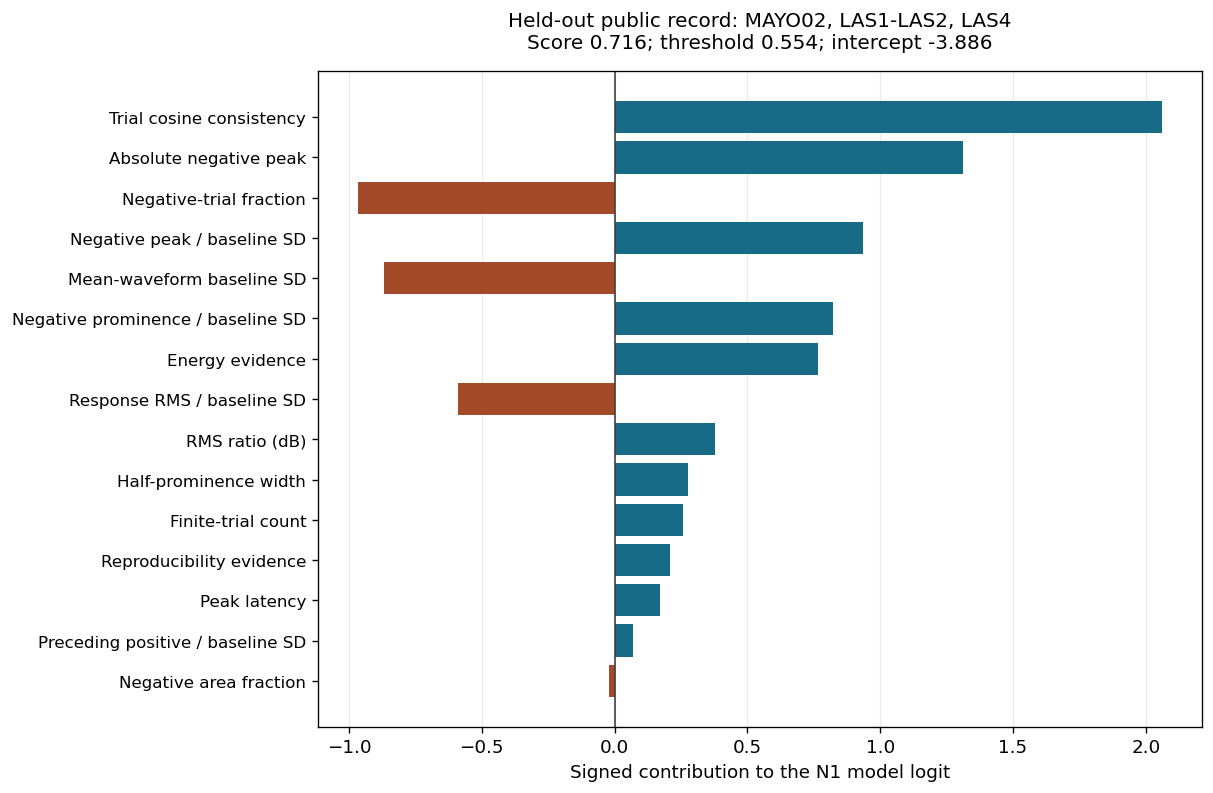

In [5]:
vector = n1_feature_vector(feature_record, inference.validated_values(feature_record))
contributions = ((vector - np.asarray(model.mean)) / np.asarray(model.scale)) * model.coefficients
logit = model.intercept + contributions.sum()
assert np.isclose(1 / (1 + np.exp(-logit)), result["score"], rtol=0, atol=1e-12)
labels = ["Negative peak / baseline SD", "Negative prominence / baseline SD", "Peak latency",
          "Half-prominence width", "Negative area fraction", "Negative-trial fraction",
          "Trial cosine consistency", "Preceding positive / baseline SD", "Response RMS / baseline SD",
          "Mean-waveform baseline SD", "Absolute negative peak", "Finite-trial count",
          "Reproducibility evidence", "Energy evidence", "RMS ratio (dB)"]
order = np.argsort(np.abs(contributions))[::-1]
fig, ax = plt.subplots(figsize=(10, 6.5), layout="constrained")
ax.barh(np.arange(len(order)), contributions[order],
        color=np.where(contributions[order] >= 0, "#176B87", "#A34A28"))
ax.set_yticks(np.arange(len(order)), np.asarray(labels)[order], fontsize=10)
ax.invert_yaxis()
ax.axvline(0, color="0.25", linewidth=1)
ax.set_xlabel("Signed contribution to the N1 model logit", fontsize=11)
ax.set_title(f"Held-out public record: {row.subject}, {row.stimpair}, {row.channel}\n"
             f"Score {result['score']:.3f}; threshold {model.threshold:.3f}; intercept {model.intercept:.3f}",
             fontsize=12, pad=14)
ax.grid(axis="x", alpha=0.25)
ax.set_axisbelow(True)
plt.show()

For new trial data, call `prepare_n1_hybrid_inputs(trials_uv, times_seconds)`
and pass the returned pair to `model.predict(*inputs)`. It constructs morphology
and trained 10–90 ms inference from the same arrays, retains their distinct
finite-trial masks, and rejects unavailable inference. Hybrid `predict` rejects
bare dictionaries because they do not establish window or trial identity.
The checked frozen-record adapter above preserves the explicit limitation that
historical clean-trial indices were not archived. Check
`available` and keep a processing no-call separate from physiological absence.
Use `measured_peak_latency_ms` for reported timing; it is unavailable when no
interior negative peak exists. `peak_latency_imputed` flags the midpoint
feature used by the classifier in that case; it is not a measured latency.
Inspect training provenance before interpreting a model on a participant.
The full-cohort `development_model` files are for further development/testing;
they must not be used to claim held-out accuracy on their training participants.

The frozen dataset license, exact checksums, all candidate results, model files,
source snapshots and reproduction commands are linked in
`validation/frozen_results/n1/README.md` and `docs/N1_DEVELOPMENT.md`.